<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/TP_IA_CreditCardFraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TP manejo de Outliers- Credit Card Fraud

-Juan Diego Ancarani

-Manuel Lafosse

-Joaquín Arpe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")


plt.rcParams["figure.figsize"] = (11, 5)
sns.set_theme(style="whitegrid")
print("✅ Librerías cargadas correctamente.")
import warnings


✅ Librerías cargadas correctamente.


1. Cargar y explorar

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print(df.info())
print(df.describe())

print(df['Class'].value_counts())

#Class → 0, 1 (Counts per type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    5974 non-null   int64  
 1   V1      5974 non-null   float64
 2   V2      5974 non-null   float64
 3   V3      5974 non-null   float64
 4   V4      5974 non-null   float64
 5   V5      5974 non-null   float64
 6   V6      5974 non-null   float64
 7   V7      5974 non-null   float64
 8   V8      5974 non-null   float64
 9   V9      5974 non-null   float64
 10  V10     5974 non-null   float64
 11  V11     5974 non-null   float64
 12  V12     5974 non-null   float64
 13  V13     5974 non-null   float64
 14  V14     5974 non-null   float64
 15  V15     5974 non-null   float64
 16  V16     5974 non-null   float64
 17  V17     5974 non-null   float64
 18  V18     5973 non-null   float64
 19  V19     5973 non-null   float64
 20  V20     5973 non-null   float64
 21  V21     5973 non-null   float64
 22  

2. Detectar Outliers

In [ ]:
Q1 = df['Amount'].quantile(0.25)
Q2 = df['Amount'].quantile(0.5)
Q3 = df['Amount'].quantile(0.75)

iqr = Q3 - Q1

upper_limit_outliers = df['Amount'] > Q3 + 1.5 * iqr
lower_limit_outliers = df['Amount'] < Q1 - 1.5 * iqr

Outliers = df[ (df['Amount'] > upper_limit_outliers) | (df['Amount'] < lower_limit_outliers)]
print('Valores (fraudes) coinsiderados Outliers: ', len(Outliers))

Valores (fraudes) coinsiderados Outliers:  5913


Umbral Z-Score: ±3
Outliers detectados : 0
Fraudes entre ellos : 0.0 (nan% de esos outliers son fraude)


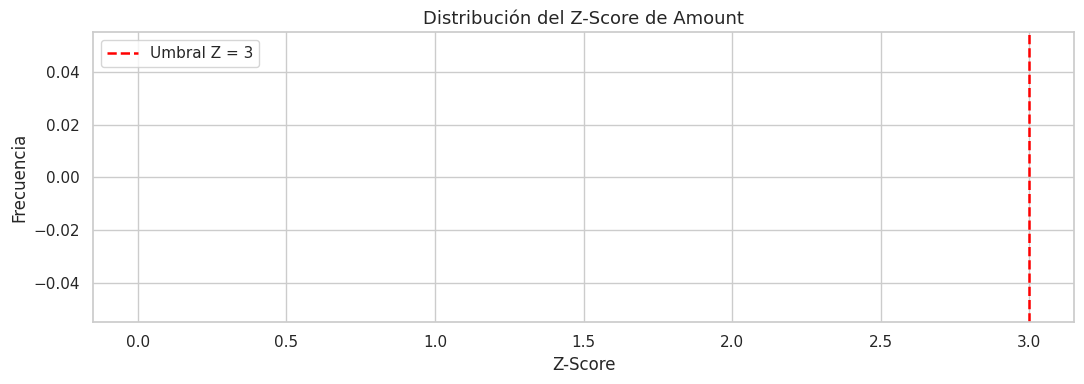

In [ ]:
#Zscore

ZSCORE_THRESH =  3
df['Zscore'] = stats.zscore(df['Amount'])
df['zscore_amount'] = np.abs(stats.zscore(df['Amount']))
df['Outliers_zscore'] = (df['Zscore'] > ZSCORE_THRESH) | (df['Zscore'] < -ZSCORE_THRESH)
outliers_z = df[df['Outliers_zscore']]

print(f"Umbral Z-Score: \u00b1{ZSCORE_THRESH}")
print(f"Outliers detectados : {len(outliers_z):,}")
print(f"Fraudes entre ellos : {outliers_z['Class'].sum()} "
      f"({outliers_z['Class'].mean()*100:.1f}% de esos outliers son fraude)")

fig, ax = plt.subplots(figsize=(11, 4))
df["zscore_amount"].hist(bins=150, ax=ax, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(ZSCORE_THRESH, color="red", linestyle="--", linewidth=1.8,
           label=f"Umbral Z = {ZSCORE_THRESH}")
ax.set_title("Distribuci\u00f3n del Z-Score de Amount", fontsize=13)
ax.set_xlabel("Z-Score")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

Contaminación configurada: 1%
Outliers detectados : 60
Fraudes entre ellos : 0.0 (0.0% de esos outliers son fraude)


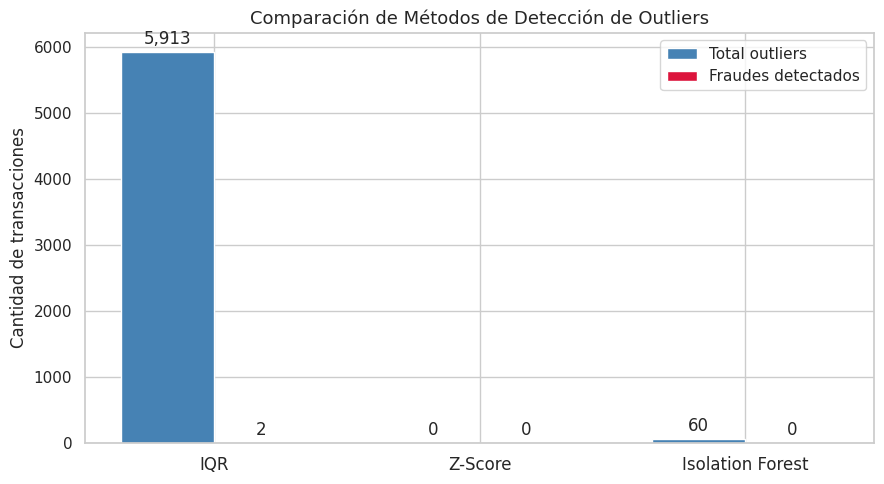

In [ ]:
features = [c for c in df.columns
            if c not in ["Class", "outlier_IQR", "outlier_Zscore", "z_score_amount"]]

scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(df[features])

iso_forest = IsolationForest(n_estimators=100, contamination=0.01,
                              random_state=42, n_jobs=-1)
df["outlier_IF"] = (iso_forest.fit_predict(X_iso_scaled) == -1).astype(int)
outliers_if = df[df["outlier_IF"] == 1]

print(f"Contaminación configurada: 1%")
print(f"Outliers detectados : {len(outliers_if):,}")
print(f"Fraudes entre ellos : {outliers_if['Class'].sum()} "
      f"({outliers_if['Class'].mean()*100:.1f}% de esos outliers son fraude)")




# ── Comparación de los tres métodos ──
methods   = ["IQR", "Z-Score", "Isolation Forest"]
total_out = [len(Outliers), len(outliers_z), len(outliers_if)]
frauds_out= [Outliers["Class"].sum(), outliers_z["Class"].sum(), outliers_if["Class"].sum()]

x = np.arange(len(methods)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, total_out,  w, label="Total outliers",     color="steelblue")
b2 = ax.bar(x + w/2, frauds_out, w, label="Fraudes detectados", color="crimson")
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=12)
ax.set_title("Comparación de Métodos de Detección de Outliers", fontsize=13)
ax.set_ylabel("Cantidad de transacciones")
ax.legend()
ax.bar_label(b1, fmt="{:,.0f}", padding=3)
ax.bar_label(b2, fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

#Estrategia A:

In [ ]:
df_base = df[["Time"] + [f"V{i}" for i in range(1,29)] + ["Amount","Class"]].copy()
df_A = df_base.copy()

p01 = df_A["Amount"].quantile(0.01)
p99 = df_A["Amount"].quantile(0.99)
df_A["Amount_wins"] = df_A["Amount"].clip(lower=p01, upper=p99)

print(f"Rango de winsorización: [{p01:.2f} €, {p99:.2f} €]")
print(f"Amount original  → Media: {df_base['Amount'].mean():.2f} | Std: {df_base['Amount'].std():.2f}")
print(f"Amount wins.     → Media: {df_A['Amount_wins'].mean():.2f} | Std: {df_A['Amount_wins'].std():.2f}")

Rango de winsorización: [0.01 €, 711.65 €]
Amount original  → Media: 65.06 | Std: 192.49
Amount wins.     → Media: 58.36 | Std: 113.45


#Estrategia b:

In [ ]:
df_B = df_base.copy()
df_B["Amount_log"] = np.log1p(df_B["Amount"])

print(f"Amount log1p → Media: {df_B['Amount_log'].mean():.4f} | Std: {df_B['Amount_log'].std():.4f}")

NameError: name 'df_B' is not defined

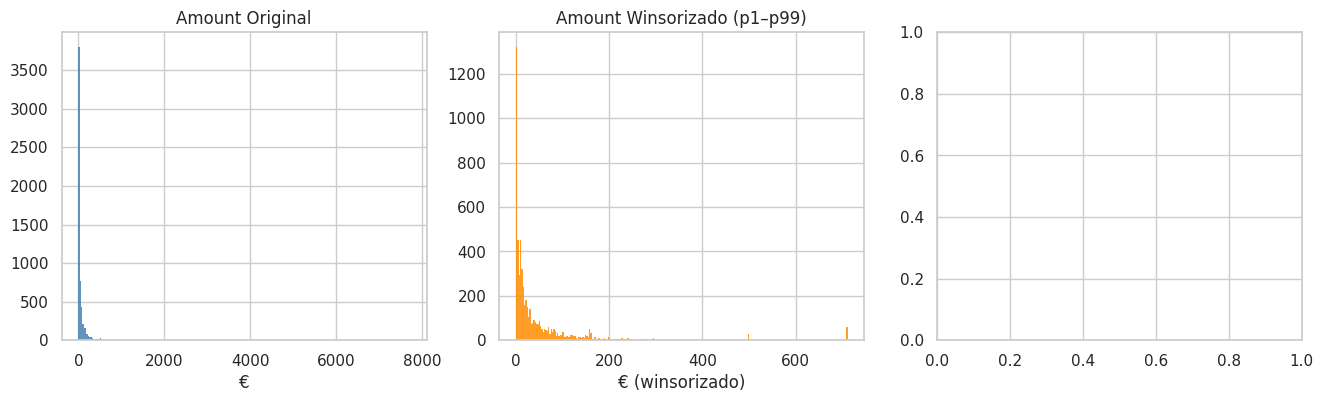

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_base["Amount"],   bins=250, color="steelblue",  edgecolor="none", alpha=0.85)
axes[0].set_title("Amount Original",              fontsize=12); axes[0].set_xlabel("€")

axes[1].hist(df_A["Amount_wins"], bins=250, color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_title("Amount Winsorizado (p1–p99)", fontsize=12); axes[1].set_xlabel("€ (winsorizado)")

axes[2].hist(df_B["Amount_log"],  bins=100, color="seagreen",   edgecolor="none", alpha=0.85)
axes[2].set_title("Amount Log-Transformado",      fontsize=12); axes[2].set_xlabel("log(1 + Amount)")

plt.suptitle("Comparación de Distribuciones de Amount", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Pregunta 1 — ¿Por qué NO eliminar outliers en este dataset?

Los outliers en este contexto **son** el fenómeno que queremos detectar: las transacciones fraudulentas.  
Solo existen **492 fraudes** sobre 284 807 transacciones (0.172%). Eliminarlos equivaldría a:

- Borrar exactamente los ejemplos que el modelo necesita aprender.
- Quedarnos con un dataset "limpio" que no detecta nada.

La regla general es: eliminar outliers solo si son **errores de carga/sensor**.  
Aquí son **señal real** de comportamiento anómalo → se conservan.  
Solo se puede tratar la *escala* de `Amount` (winsorización / log), **sin eliminar filas de fraude**.

### Pregunta 2 — ¿Isolation Forest detecta fraudes mejor que un clasificador supervisado?

**No.** Isolation Forest es **no supervisado**: no conoce las etiquetas; solo detecta anomalías estadísticas.  
Su AUC-ROC es menor al de la Regresión Logística entrenada con etiquetas reales.

| Cuándo usar Isolation Forest | Cuándo usar un clasificador supervisado |
|---|---|
| Sin etiquetas disponibles | Con etiquetas disponibles ✅ |
| Exploración / baseline rápido | Mayor precisión y recall en fraude |
| Detección en tiempo real sin reentrenamiento | Requiere reentrenamiento periódico |

En producción se suelen **combinar**: IF para ranking de anomalías + clasificador supervisado encima.

### Pregunta 3 — ¿Qué estrategia de `Amount` mejora más la detección?

Ver el gráfico de AUC-ROC de la sección 4. En general:

- **Log-transformación (`log1p`)** suele dar la mayor mejora: comprime la distribución sesgada de montos,  
  acercándola a una distribución simétrica y reduciendo el impacto de valores extremos altos.
- **Winsorización** es más conservadora: limita extremos pero mantiene la escala original  
  (útil cuando se necesita interpretabilidad del monto en euros).

> **Combinación recomendada en la práctica:** `log1p(Amount)` + `StandardScaler`.

### Conclusión general
En detección de fraude, el concepto de *"outlier"* tiene dos significados:
1. **Ruido / error** → eliminar o corregir.
2. **Señal de comportamiento anómalo real** → conservar y usar como señal para el modelo.

El analista debe distinguir ambos casos con exploración visual y conocimiento del dominio,  
**antes** de aplicar cualquier técnica de tratamiento.
